In [258]:
import pandas as pd
from tqdm import tqdm 
import scanpy as sc
import sys
import os 
import logging 
from omegaconf import OmegaConf, DictConfig
from hydra import initialize, compose
from scipy.spatial.distance import cdist
from sklearn.preprocessing import LabelEncoder
import torch
import numpy as np
from pathlib import Path 
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sc_exp_design.constants import DataFields
sys.path.insert(0, "../../shared_utils/")
from experiment_utils import (
    get_forward_model,
    get_target_dict, 
    get_loss_fn
)

logger = logging.getLogger(__name__)

In [259]:
protocol_cols = ['gm-csf_[ng_ml]', 
                 'tpo_[ng_ml]',
                 'sr1_[nm]', 
                 'um171_[nm]',
                 'um729_[µm]', 
                 'scf_[ng_ml]',
                 'butyzamide_[nm]',
                 'retinoic_acid_[µm]', 
                 'ldl_[ng_ml]', 
                 'il3_[ng_ml]', 
                 'o2_[%]',
                 'days_of_culture']

protocol_cols_l3 = protocol_cols + ["il7_[ng_ml]", "mcsf_[ng_ml]", "ly_cocktail_[ul/well]"]

In [260]:
obs_l2 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2p5/replicate/adata_500k.h5ad").obs
obs_l3_res = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop3/replicate/adata_500k_residual.h5ad").obs
adata_l3 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop3/replicate/adata_500k.h5ad")

obs_l3 = adata_l3.obs
obs_l3["Loop"] = np.where(obs_l3.experiment_number.isin(["252", 
                                                         "253", 
                                                         "254", 
                                                         "255",
                                                         "256", 
                                                         "257",
                                                         "258"]), "Loop3", "Loop2")

In [261]:
# Get protocols
obs_l2 = obs_l2.loc[:, protocol_cols].drop_duplicates().values.astype(float)
obs_l3_prot2 = obs_l3_res.loc[:, protocol_cols].drop_duplicates().values.astype(float)
adata_l2 = sc.AnnData(X=np.concatenate([obs_l2, obs_l3_prot2]))
adata_l2.obs = {"Loop": ["Loop2" for _ in range(len(obs_l2))] + ["Loop3" for _ in range(len(obs_l3_prot2))]}

In [262]:
obs_l3_prot = obs_l3.loc[:, protocol_cols_l3].drop_duplicates()
loop3_loops = obs_l3.loc[obs_l3_prot.index]["Loop"]
obs_l3 = obs_l3_prot.values.astype(float)
adata_l3 = sc.AnnData(X=obs_l3, obs={"Loop": loop3_loops})

In [263]:
sc.pp.log1p(adata_l2)
sc.tl.pca(adata_l2)
sc.pp.neighbors(adata_l2)
sc.tl.umap(adata_l2)

In [264]:
sc.pp.log1p(adata_l3)
sc.tl.pca(adata_l3)
sc.pp.neighbors(adata_l3)
sc.tl.umap(adata_l3)

## Compute the decrease of uncertainty of forward model for subsequent opt

In [265]:
def uncertainty_quantification(
    forward_model,
    base_cfg,
    X_candidates, 
    target_cell_types, 
    n_noise_samples,
    n_populations, 
    cell_type_column):
    
    protocol_columns = base_cfg["annotation"]["protocol_columns"]

    ct_le = LabelEncoder()
    ct_values = target_prediction_model.train_data.adata.obs[cell_type_column].values
    ct_le.fit(ct_values)
    classes = ct_le.classes_.tolist()  # List of cell types in alphabetical order 
    print(classes)

    # Take cell type index 
    cell_type_index = classes.index(target_cell_types)
    ct_safe_string = target_cell_types.replace("/", ":") # cell type dir

    X_candidates = torch.from_numpy(X_candidates).float().to("cuda")
    X_candidates_add = X_candidates.unsqueeze(1).repeat(1, n_noise_samples, 1)  # no_candidates x n_noise_sample x candidate_dim
    condition_repr = next(iter(forward_model.forward_model.train_data.data.perturbation_covariates))
    batch_dict = {DataFields.PERTURBATION_DATA: {condition_repr: X_candidates_add}}

    forward_out = forward_model.predict(
        batch_dict,
        no_grad=True,
        fix_noise=False,
        num_time_steps=100
    )
    
    y_pred = forward_out["target_prediction_data"][cell_type_column].view(X_candidates_add.shape[0],
                                                                     n_populations,
                                                                     -1,
                                                                     len(classes))  
    y_pred_softmax = F.softmax(y_pred, dim=-1)

    # Take the mean proportions 
    y_pred_mean = y_pred.mean(2)  # no_candidates x no_populations x no_cell_types 
    y_pred_softmax = y_pred_softmax.mean(2)  # no_candidates x no_populations x no_cell_types 
    print(y_pred_softmax[:, :, 21].mean())

    # Collect cell type of interest 
    y_pred_ct_std = y_pred_softmax[..., cell_type_index].std(1).detach().cpu().numpy()  # standard deviation prob cell type of interest 
    # Calculate loss
    y_target_ct = np.zeros((1, len(classes)))
    y_target_ct[:, cell_type_index] = 1.0
    y_target_ct = torch.from_numpy(y_target_ct)
    y_target_ct = y_target_ct.unsqueeze(0).to("cuda")  # 1 x 1 x no_cell_types
    
    logger.info("Compute loss function")
    loss_fn = lambda pred, target: -torch.sum(target*torch.nn.functional.log_softmax(pred, dim=-1), dim=-1)
    with torch.no_grad():
        loss = loss_fn(y_pred_mean, y_target_ct)  # no_candidates x no_populations

    loss_std = loss.std(1).detach().cpu().numpy()  # no_candidates
    return loss_std

In [266]:
base_config_path = "../../inverse/loss_guidance/config/"
base_config_name = "run_inverse"
target_cell_types = "late_MgkPro"
n_noise_samples = 2000
n_populations = 10
cell_type_column = "cell_type" 

# Initialize paths 
with initialize(config_path=base_config_path, version_base=None):
    cfg_l2 = compose(
        config_name=base_config_name,
        overrides=[f"paths=loop2p5_replicate", 
                   f"loss=loop2p5_replicate",
                   f"annotation=bloodplus", 
                   f"constraints=default_all_cols"])

with initialize(config_path=base_config_path, version_base=None):
    cfg_l3 = compose(
        config_name=base_config_name,
        overrides=[f"paths=loop3_replicate", 
                   f"loss=loop3_replicate",
                   f"annotation=bloodplus_loop3", 
                   f"constraints=default_all_cols_loop3"])

## Predict loop2

In [267]:
forward_model, (_, target_prediction_model) = get_forward_model(cfg_l2, logger=logger)

In [268]:
unc_l2_pred = []

for _ in tqdm(range(5)):
    unc_l2_pred.append(uncertainty_quantification(
        forward_model, 
        cfg_l2,
        adata_l2.X, 
        target_cell_types, 
        n_noise_samples,
        n_populations, 
        "cell_type_reannot_final"))

  0%|          | 0/5 [00:00<?, ?it/s]

['CD14Mono', 'CD16Mono', 'CyclingPro1', 'CyclingPro2', 'Early_GMP', 'EosBasMast1', 'EosBasMast2', 'EosBasMast3', 'EryPro', 'GMP-Neutro', 'GMP_cycling', 'HSCs', 'LMPP-CLP', 'MLP', 'MPP', 'MPP_MgkEry', 'MgKEryPro1', 'MgKEryPro2', 'ProB', 'earlyMPP', 'late_MgkPro', 'preProB', 'pre_cDC1', 'pre_cDC2']
tensor(0.0043, device='cuda:0', grad_fn=<MeanBackward0>)


 20%|██        | 1/5 [00:17<01:08, 17.18s/it]

['CD14Mono', 'CD16Mono', 'CyclingPro1', 'CyclingPro2', 'Early_GMP', 'EosBasMast1', 'EosBasMast2', 'EosBasMast3', 'EryPro', 'GMP-Neutro', 'GMP_cycling', 'HSCs', 'LMPP-CLP', 'MLP', 'MPP', 'MPP_MgkEry', 'MgKEryPro1', 'MgKEryPro2', 'ProB', 'earlyMPP', 'late_MgkPro', 'preProB', 'pre_cDC1', 'pre_cDC2']


 40%|████      | 2/5 [00:20<00:26,  8.81s/it]

...

tensor(0.0043, device='cuda:0', grad_fn=<MeanBackward0>)
['CD14Mono', 'CD16Mono', 'CyclingPro1', 'CyclingPro2', 'Early_GMP', 'EosBasMast1', 'EosBasMast2', 'EosBasMast3', 'EryPro', 'GMP-Neutro', 'GMP_cycling', 'HSCs', 'LMPP-CLP', 'MLP', 'MPP', 'MPP_MgkEry', 'MgKEryPro1', 'MgKEryPro2', 'ProB', 'earlyMPP', 'late_MgkPro', 'preProB', 'pre_cDC1', 'pre_cDC2']


 80%|████████  | 4/5 [00:26<00:04,  4.88s/it]

tensor(0.0040, device='cuda:0', grad_fn=<MeanBackward0>)
['CD14Mono', 'CD16Mono', 'CyclingPro1', 'CyclingPro2', 'Early_GMP', 'EosBasMast1', 'EosBasMast2', 'EosBasMast3', 'EryPro', 'GMP-Neutro', 'GMP_cycling', 'HSCs', 'LMPP-CLP', 'MLP', 'MPP', 'MPP_MgkEry', 'MgKEryPro1', 'MgKEryPro2', 'ProB', 'earlyMPP', 'late_MgkPro', 'preProB', 'pre_cDC1', 'pre_cDC2']


100%|██████████| 5/5 [00:29<00:00,  5.81s/it]

tensor(0.0042, device='cuda:0', grad_fn=<MeanBackward0>)


In [269]:
unc_l2_pred = np.stack(unc_l2_pred, axis=0).mean(0)

In [270]:
del forward_model
del target_prediction_model

## Predict loop3

In [271]:
forward_model, (_, target_prediction_model) = get_forward_model(cfg_l3, logger=logger)

In [272]:
unc_l3_pred = []

for _ in tqdm(range(5)):
    unc_l3_pred.append(uncertainty_quantification(
        forward_model, 
        cfg_l3,
        adata_l3.X, 
        target_cell_types, 
        n_noise_samples,
        n_populations, 
        "cell_type"))

  0%|          | 0/5 [00:00<?, ?it/s]

['CD14Mono', 'CD16Mono', 'CyclingPro1', 'CyclingPro2', 'Early_GMP', 'EosBasMast1', 'EosBasMast2', 'EosBasMast3', 'EryPro', 'GMP-Neutro', 'GMP_cycling', 'HSCs', 'LMPP-CLP', 'MLP', 'MPP', 'MPP_MgkEry', 'MgKEryPro1', 'MgKEryPro2', 'ProB', 'earlyMPP', 'late_MgkPro', 'preProB', 'pre_cDC1', 'pre_cDC2']


 20%|██        | 1/5 [00:06<00:25,  6.26s/it]

tensor(0.0030, device='cuda:0', grad_fn=<MeanBackward0>)
['CD14Mono', 'CD16Mono', 'CyclingPro1', 'CyclingPro2', 'Early_GMP', 'EosBasMast1', 'EosBasMast2', 'EosBasMast3', 'EryPro', 'GMP-Neutro', 'GMP_cycling', 'HSCs', 'LMPP-CLP', 'MLP', 'MPP', 'MPP_MgkEry', 'MgKEryPro1', 'MgKEryPro2', 'ProB', 'earlyMPP', 'late_MgkPro', 'preProB', 'pre_cDC1', 'pre_cDC2']


 40%|████      | 2/5 [00:11<00:16,  5.63s/it]

...

tensor(0.0033, device='cuda:0', grad_fn=<MeanBackward0>)
['CD14Mono', 'CD16Mono', 'CyclingPro1', 'CyclingPro2', 'Early_GMP', 'EosBasMast1', 'EosBasMast2', 'EosBasMast3', 'EryPro', 'GMP-Neutro', 'GMP_cycling', 'HSCs', 'LMPP-CLP', 'MLP', 'MPP', 'MPP_MgkEry', 'MgKEryPro1', 'MgKEryPro2', 'ProB', 'earlyMPP', 'late_MgkPro', 'preProB', 'pre_cDC1', 'pre_cDC2']


 80%|████████  | 4/5 [00:21<00:05,  5.34s/it]

tensor(0.0031, device='cuda:0', grad_fn=<MeanBackward0>)
['CD14Mono', 'CD16Mono', 'CyclingPro1', 'CyclingPro2', 'Early_GMP', 'EosBasMast1', 'EosBasMast2', 'EosBasMast3', 'EryPro', 'GMP-Neutro', 'GMP_cycling', 'HSCs', 'LMPP-CLP', 'MLP', 'MPP', 'MPP_MgkEry', 'MgKEryPro1', 'MgKEryPro2', 'ProB', 'earlyMPP', 'late_MgkPro', 'preProB', 'pre_cDC1', 'pre_cDC2']


100%|██████████| 5/5 [00:27<00:00,  5.41s/it]

tensor(0.0030, device='cuda:0', grad_fn=<MeanBackward0>)


In [273]:
unc_l3_pred = np.stack(unc_l3_pred, axis=0).mean(0)

# Plot both uncertanties and also new recipes

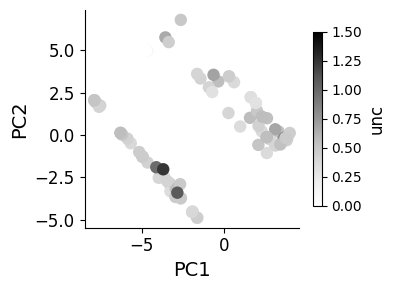

In [274]:
fig, ax = plt.subplots(figsize=(4, 3))

# Split by Loop
mask_loop2 = adata_l2.obs["Loop"] == "Loop2"
mask_loop3 = adata_l2.obs["Loop"] == "Loop3"

pca_coords = adata_l2.obsm["X_pca"]

# Loop0: colored by unc_delta (continuous colormap)
sc_plot = ax.scatter(
    pca_coords[mask_loop2, 0],
    pca_coords[mask_loop2, 1],
    c=unc_l2_pred[mask_loop2],
    cmap="Greys",
    vmin=0,
    vmax=1.5,
    s=80,
    edgecolor="none",
    marker="o",
    label="Loop0",
)

# Colorbar for the uncertainty values
cbar = plt.colorbar(sc_plot, ax=ax, shrink=0.8)
cbar.set_label("unc", fontsize=12)

ax.set_xlabel("PC1", fontsize=14)
ax.set_ylabel("PC2", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.spines[["top", "right"]].set_visible(False)
# ax.legend(fontsize=11, loc="best", frameon=True)

plt.tight_layout()
plt.show() 

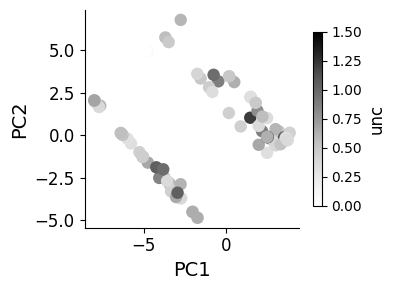

In [288]:
fig, ax = plt.subplots(figsize=(4, 3))

pca_coords = adata_l3.obsm["X_pca"]

# Loop0: colored by unc_delta (continuous colormap)
sc_plot = ax.scatter(
    pca_coords[:, 0],
    pca_coords[:, 1],
    c=unc_l3_pred,
    cmap="Greys",
    vmin=0,
    vmax=1.5,
    s=80,
    edgecolor="none",
    marker="o",
)

# Colorbar for the uncertainty values
cbar = plt.colorbar(sc_plot, ax=ax, shrink=0.8)
cbar.set_label("unc", fontsize=12)

ax.set_xlabel("PC1", fontsize=14)
ax.set_ylabel("PC2", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.spines[["top", "right"]].set_visible(False)
# ax.legend(fontsize=11, loc="best", frameon=True)

plt.tight_layout()
plt.show() 